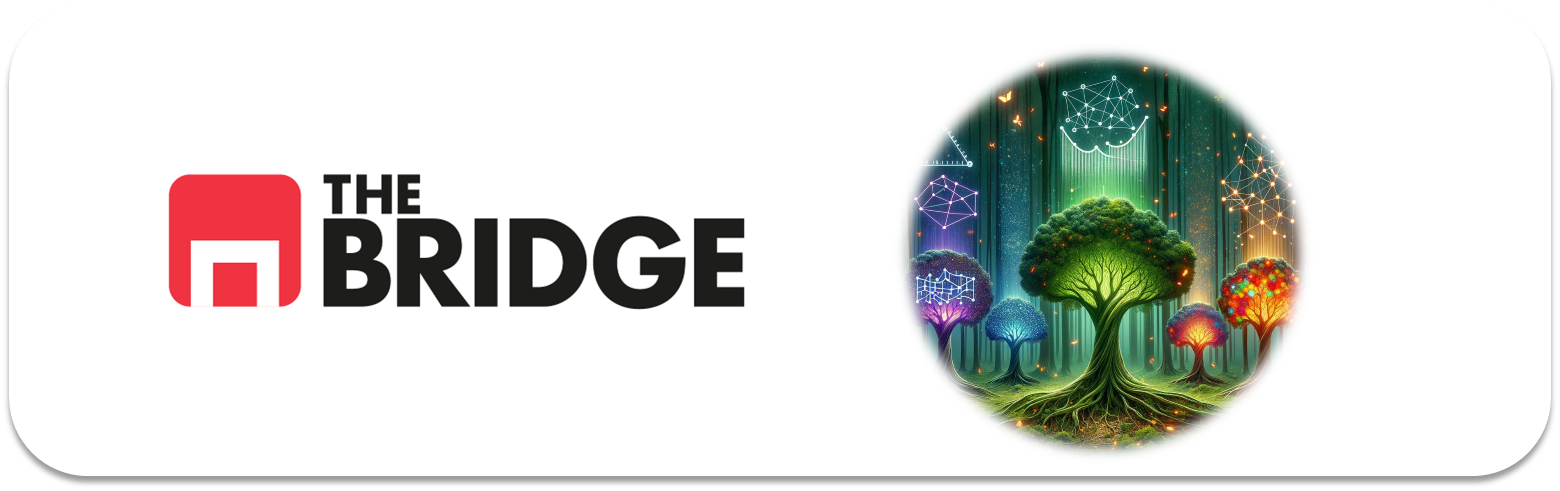

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [36]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

df= pd.read_csv(url, names=names)

In [37]:
df.head(20) # Echamos un vistazo a los valores del dataset

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [38]:
df.info() # El dataset no tiene nulos y todas las variables son numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [39]:
df.describe() # Valores descriptivos de las variables del dataset 

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Elementos que llaman la atención en el dataset

1. **preg - Número de Embarazos**: la media es elevada -> 3,8 hijos por mujer. Y el mínimo no puede ser 0.
2. **plas - Concentración de Glucosa en Plasma**: valores entre 100 y 125 mg/dL indican prediabetes. La media es 120. Y además el mínimo no puede ser 0 tampoco. 
3. **press - Presión Arterial Diastólica**: la presión está < 80 mmHg, lo cual es una cifra normal y estándar. Pero una vez más el mínimo no puede ser 0 tampoco. 
4. **skin - Grosor del Pliegue Cutáneo del Tríceps**: 20.5 mm es la media, lo cual no indica sobrepeso. Pero pasa lo mismo con el mínimo, no puede ser 0 tampoco. 
6. **mass - Índice de Masa Corporal**: la media está situada en 32kg/m2, lo cual es sobrepeso sobre el estándar. Y además el mínimo no puede ser 0 tampoco.  
8. **age - Edad**: la media de edad de las mujeres del estudio son 33 años. 
9. **class - Variable Objetivo**: esta es la variable target -> desarrollaron (1) o no (0) diabetes.

**Puntualización**: el tema es que todos esos valores mínimos de 0 alteran los percentiles porque introducen valores bajos en el cálculo, valores que son irreales. 

<Axes: xlabel='plas', ylabel='Count'>

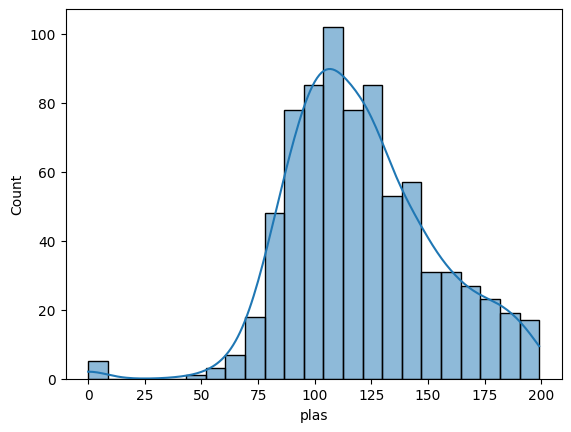

In [66]:
# Usamos histograma para ver las curvas de las variables que tiene valores 0 extraños

sns.histplot(x= "plas", data = df, kde = True) # Aquí se ven los valores artificiales de 0 en Concentración de Glucosa en sangre

<Axes: xlabel='pres', ylabel='Count'>

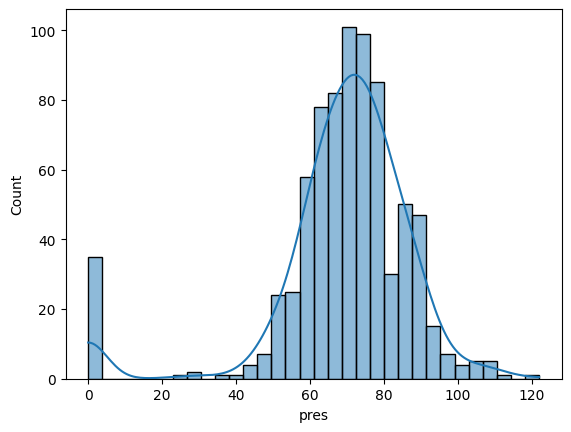

In [ ]:
sns.histplot(x= "pres", data = df, kde = True) # Aquí se ven los valores artificiales de 0 en Presión Arterial

<Axes: xlabel='skin', ylabel='Count'>

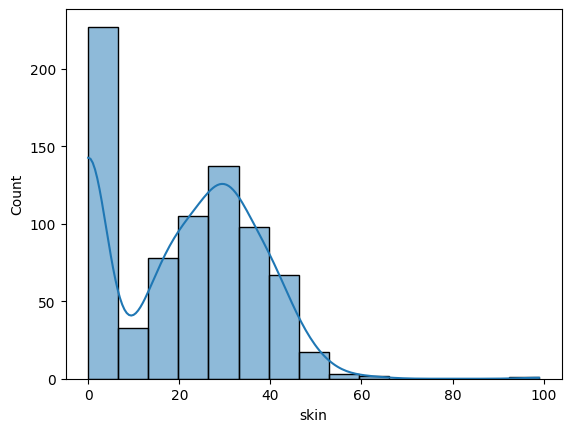

In [ ]:
sns.histplot(x= "skin", data = df, kde = True) # Aquí se ven los valores artificiales de 0 en Grosor de Pliegue Cutáneo en Triceps

<Axes: xlabel='test', ylabel='Count'>

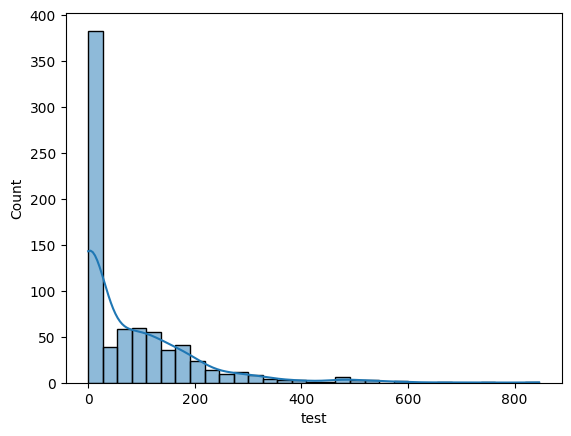

In [65]:
sns.histplot(x= "test", data = df, kde = True) # Aquí se ven los valores artificiales de 0 en Insulina en suero

<Axes: xlabel='mass', ylabel='Count'>

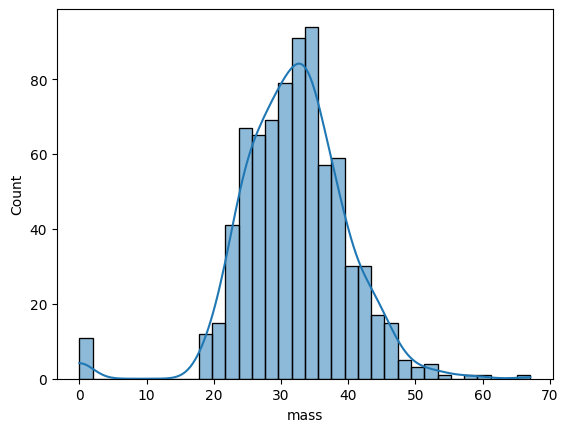

In [ ]:
sns.histplot(x= "mass", data = df, kde = True) # Aquí se ven los valores artificiales de 0 en índice de Masa Corporal

In [40]:
# Si convertirmos esos valores 0 en valores faltantes y volvemos a crear un dataset nuevo...
# ... Quizás podemos volver a extraer los valores descriptivos y ver la diferencia entre los dos datasets
# Hacemos primero una copia del dataset original para no perderlo

df_nan = df.copy()

In [41]:
# Hacemos el replace de los valores 0 por valores faltantes y no alterar el cálculo de los valores descriptivos
# Ese reemplazo lo hacemos solo sobre las columnas con valores mínimos de 0 irreales

cols_zeros = ['plas', 'pres', 'skin', 'test', 'mass']

df_nan[cols_zeros] = df_nan[cols_zeros].replace(0,np.nan)

print(df_nan.isnull().sum()) # Imprimimos la suma de valores faltantes en cada columnas del dataset 

preg       0
plas       5
pres      35
skin     227
test     374
mass      11
pedi       0
age        0
class      0
dtype: int64


In [42]:
df_nan.info() # Aquí podemos ver también el volumen de valores faltantes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    763 non-null    float64
 2   pres    733 non-null    float64
 3   skin    541 non-null    float64
 4   test    394 non-null    float64
 5   mass    757 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [43]:
df_nan.describe() # Aquí ya podemos ver que los valores descriptivos cambian sobre le dataset original 

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Elementos que llaman la atención en el dataset modificado vs el dataset original

1. **plas - Concentración de Glucosa en Plasma**: valores entre 100 y 125 mg/dL indican prediabetes. La media ha pasado de 120mg/dL a 121.6. Sube levemente y acentúa el estado de prediabetes en el grupo de mujeres del estudio. 
2. **press - Presión Arterial Diastólica**: la presión sigue estando < 80 mmHg, aunque haya pasado de valores de 69 a 72, lo cual es una cifra normal y estándar. 
3. **skin - Grosor del Pliegue Cutáneo del Tríceps**: aquí existe una alteración considerable de los valores de 20.5 mm a 29 mm. Y en los nuevos rangos pasamos de tener valores estándar a indicar sobrepeso en las pacientes. 
4. **mass - Índice de Masa Corporal**: la media sube ligeramente por encima de 32, lo cual es sobrepeso sobre el estándar.

In [44]:
# Ahora no podemos tener un dataset con valores faltantes. 
# Al ser variables numéricas, imputamos los valores nulos usando la mediana
# Hacemos una copia para no perder el dataset intermedio antes de hacer la imputación 

df_clean = df_nan.copy()

In [45]:
df_clean = df_clean.fillna(df_clean.median())

In [46]:
df_clean.info() 

# Ahora no tenemos valores nulos pero tampoco tenemos falsos valores 0
# Los valores 0 los hemos sustituido por medianas  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   test    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


### **Hacemos un mini-EDA**

array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'test'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'class'}>]], dtype=object)

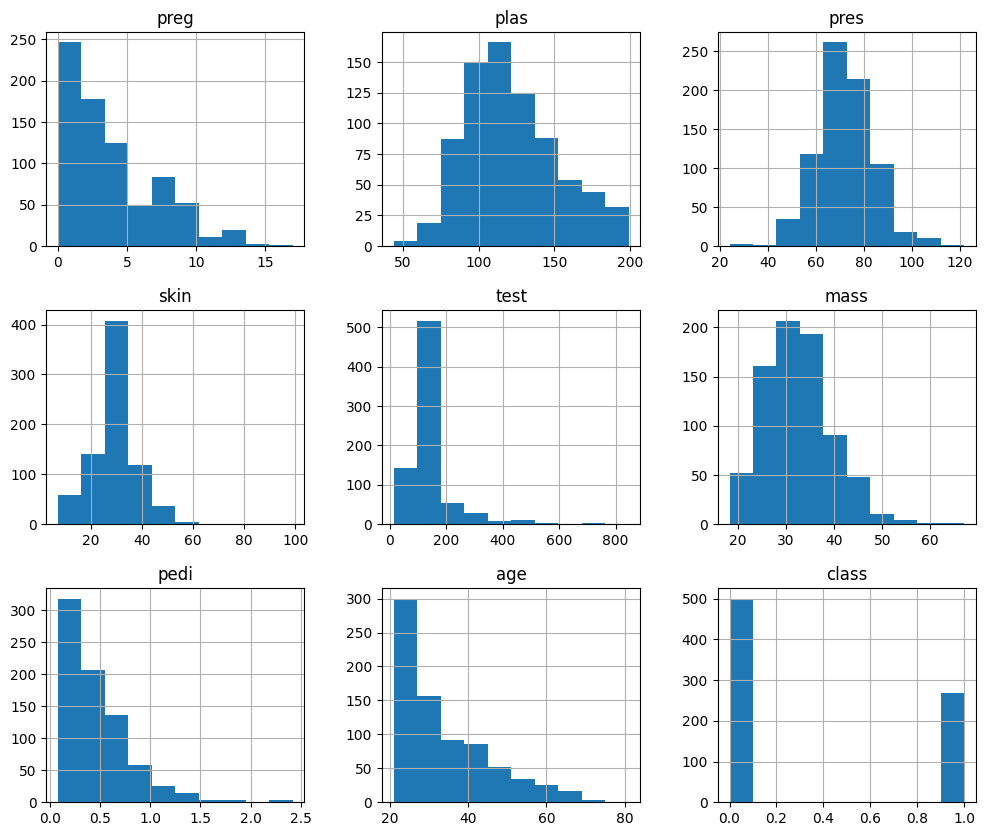

In [47]:
# Pintamos un matriz de histogramas con todas las variables para ver su distribución

df_clean.hist(figsize=(12, 10))

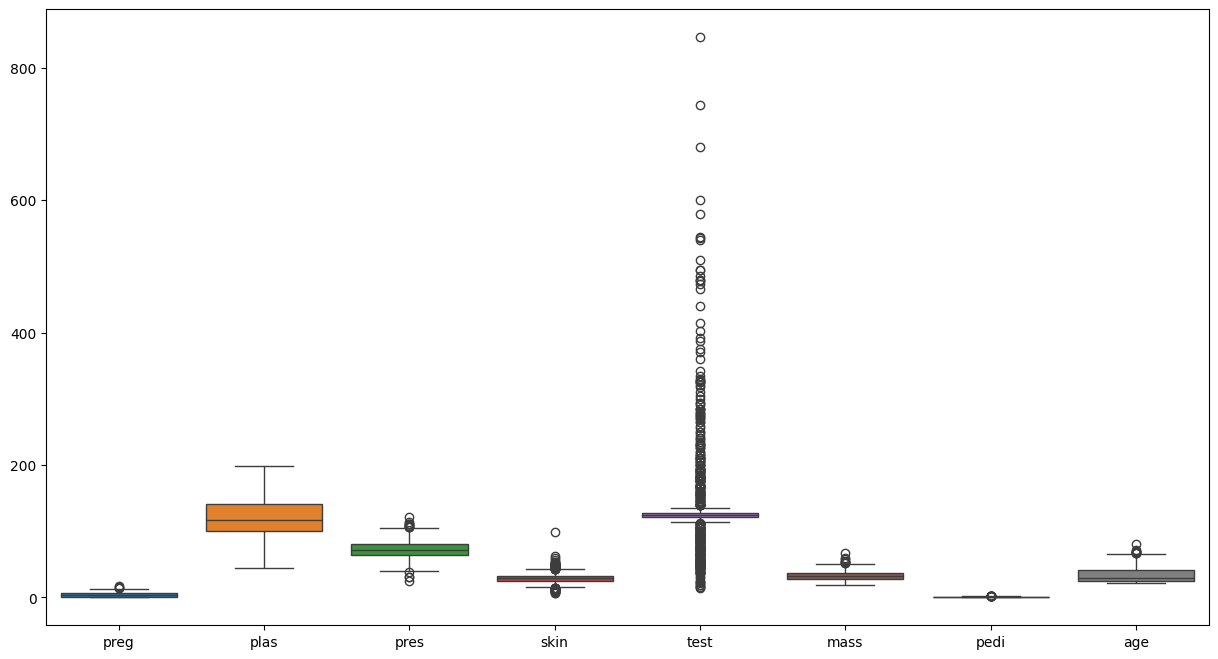

In [48]:
# Boxplots para ver valores atípicos en las variables

plt.figure(figsize=(15,8))
sns.boxplot(data=df_clean.drop(columns=['class']))
plt.show()

Elementos que llaman la atención en los boxplot:

Las variables `pres`, `skin`, `test`, y `mass` tienen outliers significativos. Básicamente todo marcadores de riesgo de diabetes. 

- **Presión Arterial Diastólica**.
- **Grosor del Pliegue Cutáneo del Tríceps**.
- **Insulina en Suero**.
- **Índice de Masa Corporal**.
- **Función del Pedigree de Diabetes**.

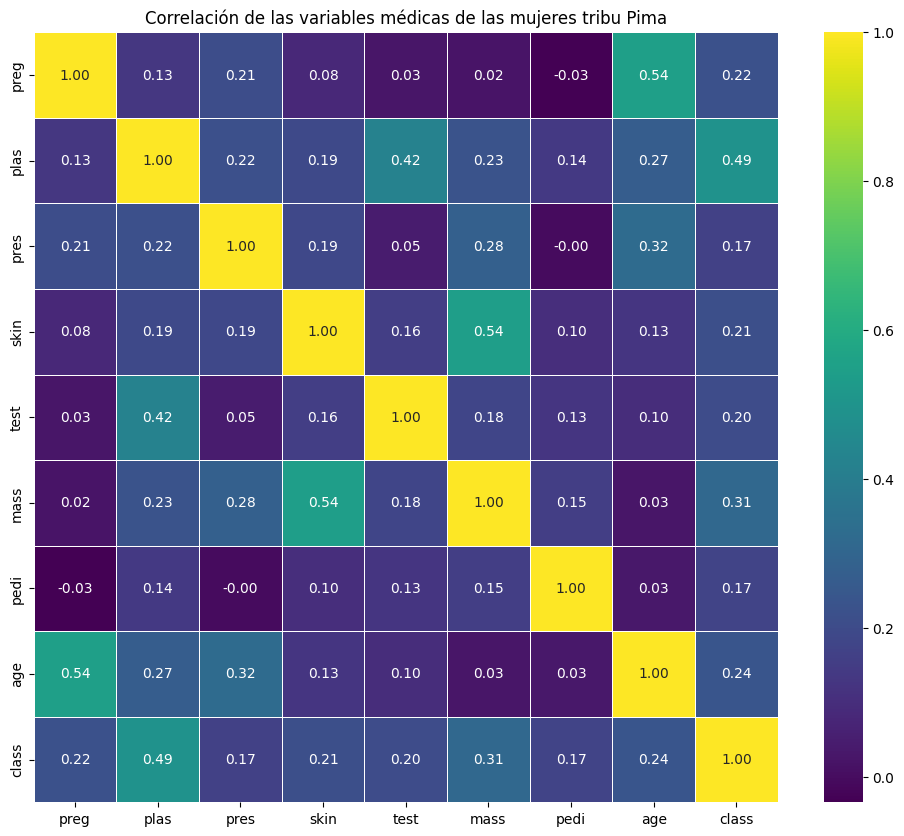

In [49]:
# Analizamos las correlaciones entre variables numéricas con un heatmap

matriz_correlacion = df_clean.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlación de las variables médicas de las mujeres tribu Pima')
plt.show()

In [50]:
# Vemos los valores de correlación solo con la variable target (class)

corr_target = df_clean.corr()['class'].sort_values(ascending=False)
print(corr_target)


class    1.000000
plas     0.492782
mass     0.312038
age      0.238356
preg     0.221898
skin     0.214873
test     0.203790
pedi     0.173844
pres     0.165723
Name: class, dtype: float64


Correlaciones interesantes: 

1. La mayor correlación la gtenemos entre la **Concentración de Glucosa en Plasma** y el desarrollo de diabetes. 
2. La segunda correlación a destacar es el **Índice de Masa Corporal**. También parece un posible predictor de diabetes. 
3. Luego existen variables con correlaciones más débiles como **Edad** y **Número de embarazos**.

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

### **Hacemos el split de los datasets de entrenamiento y test**

In [67]:
# Instancionamos la variable target de nuestro modelo

target = 'class'

# Creamos una copia del dataset para no alterar pasos anteriores 

df_train = df_clean.copy()

In [ ]:
# Hacemos el split del dataset

train_set, test_set = train_test_split(df_train, test_size= 0.2, random_state= 42, stratify=df_train[target])

In [69]:
# Definimos las variables y las separamos a partir del split  

features = train_set.columns.to_list()
features.remove(target)

X_train = train_set[features]
y_train = train_set[target] 
X_test = test_set[features]
y_test = test_set[target] 

In [70]:
# Hacemos un escalado de las variables 
# Esto es obligatorio porque tenemos variables con valores cercanos a 800 ('test') y otras con valores radicalmente más bajos ('preg')

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns= features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = features)

array([[<Axes: title={'center': 'preg'}>,
        <Axes: title={'center': 'plas'}>,
        <Axes: title={'center': 'pres'}>],
       [<Axes: title={'center': 'skin'}>,
        <Axes: title={'center': 'test'}>,
        <Axes: title={'center': 'mass'}>],
       [<Axes: title={'center': 'pedi'}>,
        <Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

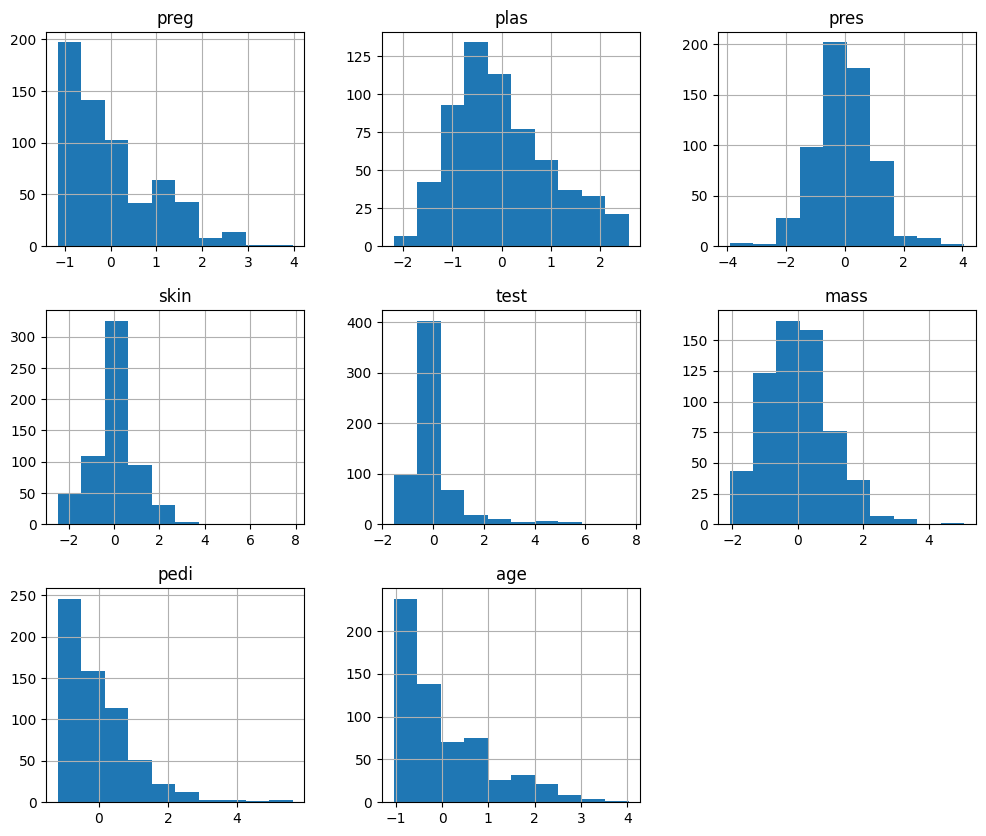

In [ ]:
X_train_scaled.hist(figsize=(12, 10)) 

# Aquí podemos ver la distribución de las variables ya escaladas 
# Ya tenemos todas en valores comparables para que no ponderen de forma irregular en el modelo 

### **Modelos a probar**

1. **Los modelos que vamos a probar son modelos de clasificación**
2. **Elegimos modelos de clasificación porque la respuesta que esperamos es Enferma / No enferma**
3. Hacemos primero un comparación cruzada entre modelos para ver inicialmente quién resuelve mejor el problema de predicción.

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


model_names = ["Logistic Regression","DecisionTree","Random Forest","XGBoost","LightGBM","CatBoost"]
lr_clf = LogisticRegression(max_iter=1000)
tree_clf = DecisionTreeClassifier(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
xgb_clf = XGBClassifier(random_state=42)
lgb_clf = LGBMClassifier(random_state=42, verbose=-100)
cat_clf = CatBoostClassifier(random_state=42, verbose=False)
model_set = [lr_clf, tree_clf, rf_clf, xgb_clf, lgb_clf, cat_clf]

In [77]:
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(modelo)
    if nombre != "Logistic Regression":
        metricas_cv[nombre] = cross_val_score(modelo, X_train, y_train, cv = 3, scoring = "accuracy")
    else:
        metricas_cv[nombre] = cross_val_score(modelo, X_train_scaled, y_train, cv = 3, scoring = "accuracy")
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmax(valores)]

LogisticRegression(max_iter=1000)
DecisionTreeClassifier(random_state=42)
RandomForestClassifier(random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
LGBMClassifier(random_state=42, verbose=-100)


In [78]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, Accuracy_CV: {np.mean(valores)}")
print(f"El ganador es {ganador}")

Model <Logistic Regression>, Accuracy_CV: 0.7818029650884745
Model <DecisionTree>, Accuracy_CV: 0.6938227323449704
Model <Random Forest>, Accuracy_CV: 0.767136936075243
Model <XGBoost>, Accuracy_CV: 0.7296429140761996
Model <LightGBM>, Accuracy_CV: 0.7459668420213613
Model <CatBoost>, Accuracy_CV: 0.7639008448908019
El ganador es Logistic Regression


Algunas conclusiones interesantes: 

1. Parece que el modelo de Regresión Logísica es el que mejor se comporta previo a la optimización de los propios modelo. 
2. Y los siguientes modelos en precisión sería Ramdom Forest y CatBoost. 

#### **Vamos a optimizar los modelos para luego ver quién se comporta realmente mejor para las métricas relevantes**

- La evaluación previa en la métrica de accuracy está bien para ganar contexto con los modelos. 
- Pero en este caso nuestro modelo funcionará mejor si mejoras la performance en recall -> capacidad para detectar todos los positivos reales.

#### Esta es la optimización del modelo ganador --> Regresión Logística

In [99]:
# Optimización del modelo de Regresión Logística 

metricas_optimizadas = {}

param_grid = {
    "max_iter": [1000, 2000, 5000],
    "penalty": ["l2", None],
    "C": [0.1, 0.5, 1, 10] 
} 

model = LogisticRegression() # lbfgs es el estándar actual

lr_grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10, 
    scoring="balanced_accuracy"
)

lr_grid.fit(X_train_scaled, y_train)

print("Mejor Recall encontrado:", lr_grid.best_score_)
print("Mejores Parámetros:", lr_grid.best_params_)
metricas_optimizadas["LogisticRegression"] = lr_grid.best_score_

c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py

Mejor Recall encontrado: 0.743241341991342
Mejores Parámetros: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2'}


c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1208: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py

In [100]:
lr_grid.best_score_

np.float64(0.743241341991342)

In [101]:
lr_grid.best_params_

{'C': 0.1, 'max_iter': 1000, 'penalty': 'l2'}

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.35      1.00      0.52        54

    accuracy                           0.35       154
   macro avg       0.18      0.50      0.26       154
weighted avg       0.12      0.35      0.18       154



c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jcia.ELCONFIDENCIAL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

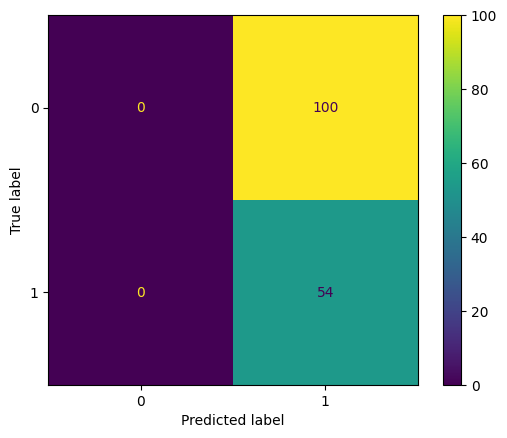

In [102]:
y_pred = lr_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

#### Esta es la optimización para recall del segundo modelo en la precisión inicial --> Random Forest

1. He intentado optimizarlos con GridSV pero es mucho más costoso en tiempos. 
2. Con este volumen de registros sería mejor opción, al verdad. 
3. Como alternativa he utilizado RandomizedSV, que no revisa todas las combinaciones posibles de la matriz, pero nos da un scoring. 

In [118]:
rf_clf = RandomForestClassifier()

params_grid_rf = {
    "n_estimators": [100,200,400],
    "max_depth": [2,4,10],
    "min_samples_leaf": [10,20,40],
    "max_features": ["sqrt","log2",None],
    "max_samples": [0.3,0.6,1]
}

rf_grid = RandomizedSearchCV(
    rf_clf, 
    param_distributions=params_grid_rf,
    cv=10,
    n_iter = 20,
    scoring="balanced_accuracy",
    n_jobs=-1,
    random_state=42 
)

rf_grid.fit(X_train, y_train)
print("Mejor Recall encontrada:", rf_grid.best_score_)
print("Mejores parámetros encontrados:", rf_grid.best_params_)
metricas_optimizadas["RandomForest"] = rf_grid.best_score_

Mejor Recall encontrada: 0.728349567099567
Mejores parámetros encontrados: {'n_estimators': 400, 'min_samples_leaf': 10, 'max_samples': 0.6, 'max_features': None, 'max_depth': 10}


#### Esta es la optimización para recall del tercer modelo en la precisión inicial --> CatBoost

In [117]:
cat_clf = CatBoostClassifier(verbose = False)

param_grid_cat= {'depth': [2, 4, 6],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'colsample_bylevel': [0.5,1],
          'iterations': [100, 250, 500, 750],
          "border_count": [125,250]
          }

cat_grid = RandomizedSearchCV(cat_clf, 
                        cv = 10,
                        n_iter = 20,
                        param_distributions= param_grid_cat, 
                        scoring = "balanced_accuracy",
                        n_jobs=-1,
                        random_state=42
                        )


cat_grid.fit(X_train, y_train)
print("Mejor Recall encontrada:", cat_grid.best_score_)
print("Mejores parámetros encontrados:", cat_grid.best_params_)
metricas_optimizadas["CatBoost"] = cat_grid.best_score_

Mejor Recall encontrada: 0.7413203463203464
Mejores parámetros encontrados: {'learning_rate': 0.1, 'iterations': 100, 'depth': 4, 'colsample_bylevel': 0.5, 'border_count': 250}


#### Incluimos la cuarta opción en la precisión inicial --> LightGBM. Pero optimizado para balanced_accuracy 

In [114]:
lgb_clf = LGBMClassifier(verbose = -100)

param_grid_lgb = {'max_depth': [2, 4, 6],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'bagging_fraction': [0.3,0.6,1],
          'feature_fraction': [0.5,1],
          'n_estimators': [100, 250, 500, 750],
          'max_bins': [125,250]
          }

lgb_grid = RandomizedSearchCV(lgb_clf, 
                        cv = 10,
                        n_iter = 20,
                        param_distributions= param_grid_lgb, 
                        scoring = "balanced_accuracy",
                        n_jobs=-1,
                        random_state=42
                        )


lgb_grid.fit(X_train, y_train)
print("Mejor Recall encontrada:", lgb_grid.best_score_)
print("Mejores parámetros encontrados:", lgb_grid.best_params_)
metricas_optimizadas["LightGBM"] = lgb_grid.best_score_

Mejor Recall encontrada: 0.7053030303030303
Mejores parámetros encontrados: {'n_estimators': 100, 'max_depth': 4, 'max_bins': 250, 'learning_rate': 0.1, 'feature_fraction': 0.5, 'bagging_fraction': 1}


#### Incluimos la quinta opción en la precisión inicial viendo el buen resultados de LightGBM--> XGBoost. Pero optimizado para balanced_accuracy

In [112]:
xgb_clf = XGBClassifier()

param_grid_xgb = {'max_depth': [2, 4, 6],
          'learning_rate': [0.1, 0.2, 0.3, 0.4],
          'subsample': np.arange(0.5, 1.0, 0.1),
          'colsample_bytree': np.arange(0.5, 1.0, 0.1),
          'colsample_bylevel': np.arange(0.5, 1.0, 0.1),
          'n_estimators': [100, 200, 300],
          }

xgb_grid = RandomizedSearchCV(xgb_clf,
                              cv = 10,
                              n_iter = 20,
                              param_distributions= param_grid_xgb, 
                              scoring = "balanced_accuracy",
                              n_jobs=-1,
                              random_state=42
                              )


xgb_grid.fit(X_train, y_train)
print("Mejor Recall encontrada:", xgb_grid.best_score_)
print("Mejores parámetros encontrados:", xgb_grid.best_params_)
metricas_optimizadas["XGBoost"] = xgb_grid.best_score_

Mejor Recall encontrada: 0.724724025974026
Mejores parámetros encontrados: {'subsample': np.float64(0.8999999999999999), 'n_estimators': 100, 'max_depth': 2, 'learning_rate': 0.2, 'colsample_bytree': np.float64(0.8999999999999999), 'colsample_bylevel': np.float64(0.5)}


In [119]:
for model_name, valores in metricas_optimizadas.items():
    print(f"Model <{model_name}>, Accuracy_CV: {np.mean(valores)}")
print(f"El ganador es {ganador}")

Model <LogisticRegression>, Accuracy_CV: 0.743241341991342
Model <CatBoost>, Accuracy_CV: 0.7413203463203464
Model <LightGBM>, Accuracy_CV: 0.7053030303030303
Model <XGBoost>, Accuracy_CV: 0.724724025974026
Model <RandomForest>, Accuracy_CV: 0.728349567099567
El ganador es Logistic Regression


### **Volvemos a comparar los  modelos, pero esta vez con las métricas optimizadas**

1. **Regresión logísitica** de mantiene como el modelo ganador. 
2. **CastBoost** sube a la segunda posición. 
3. **Random Forest** y **XGBoost** serían el tercer y cuarto modelo en recall. 
4. Lejos quedaría ya el modelo de boosting **LightGBM**. 

--

**Aclaración**: seguramente pruebe los mismo modelos con GridSV para comparar las métricas. 

**Aclaración 2**: he investigado y parece que balance_accuracy y recall son dos métricas diferentes. Podríamos optimizar para recall.